# Nura Health — ML Pipeline
## Child Malnutrition Screening for Community Health Workers in Rwanda
### Dataset: Rwanda DHS 2020 (RWKR81DT) — 3,436 children under 5
---
**Research:** Improving child malnutrition detection by comparing three ensemble ML models  
(Random Forest, XGBoost, Voting Ensemble) on Rwanda-specific DHS data, targeting >92% accuracy


## Section 0 — Google Colab + Google Drive setup

This makes the notebook run end-to-end in Google Colab using a dataset stored in **Google Drive**.

In [14]:
# ============================================================
# SECTION 0 — SETUP
# Installs the extra packages on Google Colab,
# ============================================================
import os, sys, subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Google Colab detected — installing dependencies (one moment)...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "imbalanced-learn", "shap", "xgboost"],
        check=False,
    )

# Make sure the folders the later cells read from / write to exist.
for _d in ("../data", "../models", "../outputs"):
    os.makedirs(_d, exist_ok=True)

_csv_path = "../data/rwanda_dhs_clean.csv"
if os.path.exists(_csv_path):
    print("\u2713 Dataset found:", os.path.abspath(_csv_path))
else:
    print("\u26a0 Dataset not found at", _csv_path)
    print("  Run this notebook from the repo's notebooks/ folder, with the")
    print("  data/ folder beside it. On Colab, upload data/rwanda_dhs_clean.csv first.")

print("\u2713 Setup complete — now use Runtime -> Run all.")


Google Colab detected — installing dependencies (one moment)...
✓ Dataset found: /content/drive/MyDrive/Nurahealth/data/rwanda_dhs_clean.csv
✓ Setup complete — now use Runtime -> Run all.


## Section 1 — Data Loading and Visualisation

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Rwanda DHS 2020 clean data
df = pd.read_csv('../data/rwanda_dhs_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nData sample:")
df.head()

Dataset shape: (3436, 9)

Column names: ['age_months', 'weight_kg', 'height_cm', 'muac_mm', 'sex_encoded', 'whz_score', 'waz_score', 'haz_score', 'label']

Class distribution:
label
normal             2229
wasted              882
severely_wasted     325
Name: count, dtype: int64

Data sample:


,age_months,weight_kg,height_cm,muac_mm,sex_encoded,whz_score,waz_score,haz_score,label
0,37,12.4,89.1,13.8,0,-2.17,-1.38,-0.27,wasted
1,10,10.8,69.7,8.5,1,-0.90,1.86,3.00,normal
2,53,18.2,100.4,13.4,1,-1.20,0.45,1.82,normal
3,59,14.2,102.9,13.0,1,-1.35,-1.74,-1.40,normal
4,32,10.7,82.8,11.7,1,-2.75,-1.76,-0.16,wasted


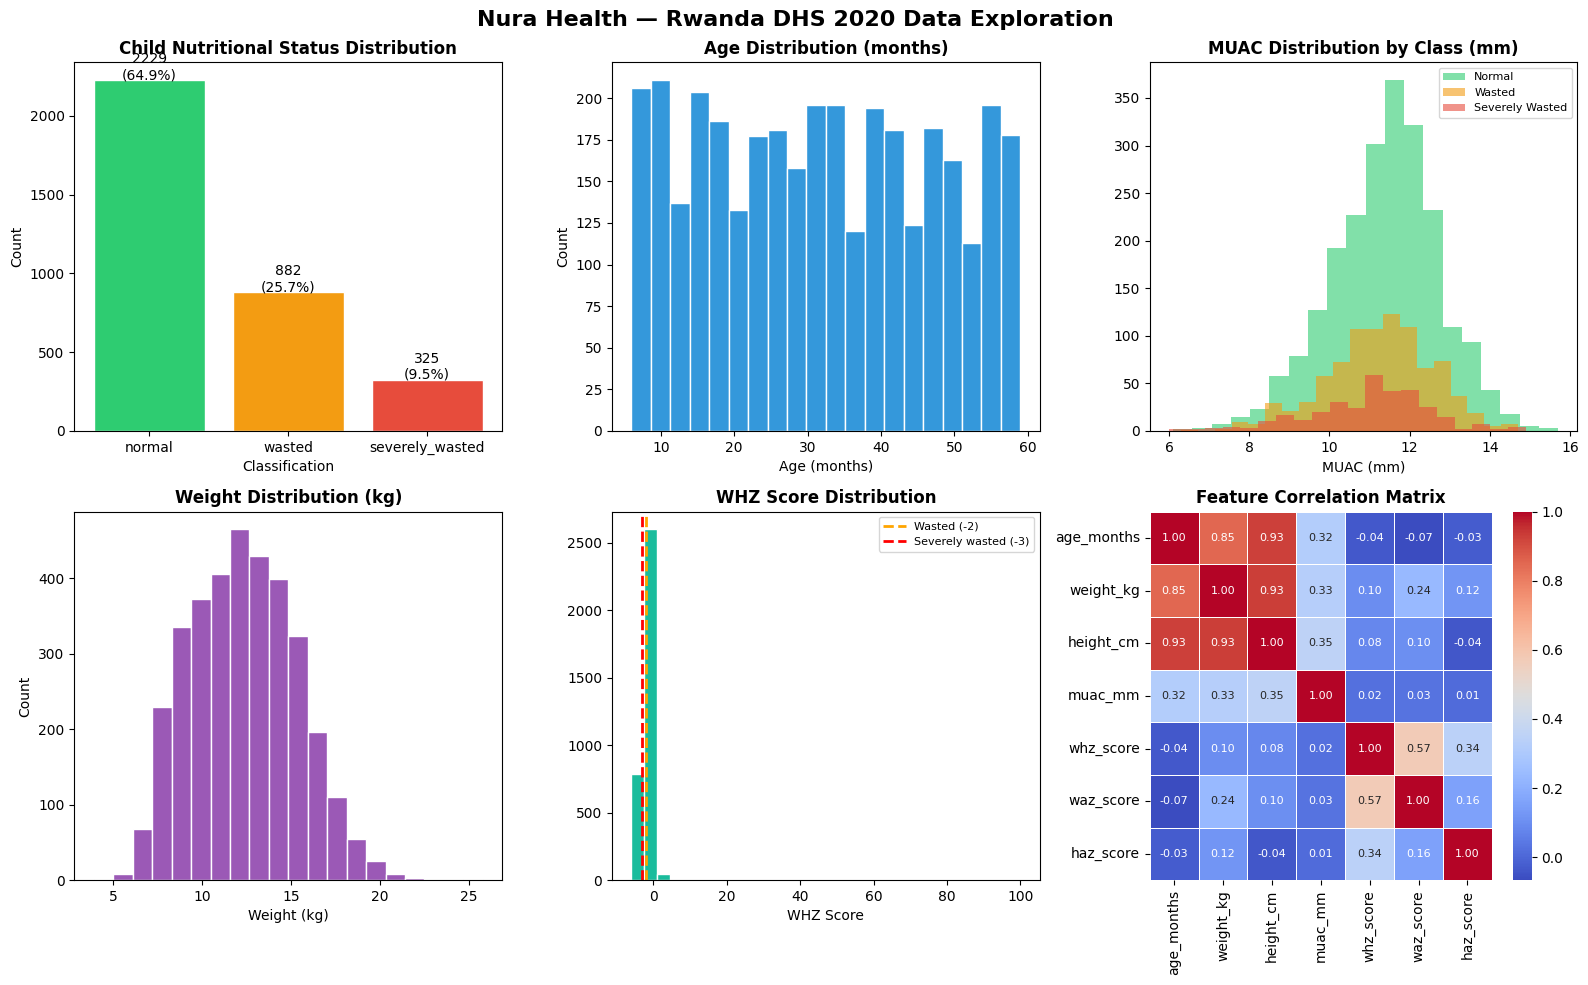

✓ Data exploration plots saved


In [16]:
# 1. Class Distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Nura Health — Rwanda DHS 2020 Data Exploration', fontsize=16, fontweight='bold')

colors = {'normal':'#2ecc71','wasted':'#f39c12','severely_wasted':'#e74c3c'}
counts = df['label'].value_counts()
bars = axes[0,0].bar(counts.index, counts.values,
                     color=[colors[l] for l in counts.index], edgecolor='white')
axes[0,0].set_title('Child Nutritional Status Distribution', fontweight='bold')
axes[0,0].set_xlabel('Classification'); axes[0,0].set_ylabel('Count')
for bar, count in zip(bars, counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                   f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=10)

# 2. Age Distribution
axes[0,1].hist(df['age_months'], bins=20, color='#3498db', edgecolor='white')
axes[0,1].set_title('Age Distribution (months)', fontweight='bold')
axes[0,1].set_xlabel('Age (months)'); axes[0,1].set_ylabel('Count')

# 3. MUAC by class
for label, color in colors.items():
    axes[0,2].hist(df[df['label']==label]['muac_mm'], alpha=0.6,
                   label=label.replace('_',' ').title(), color=color, bins=20)
axes[0,2].set_title('MUAC Distribution by Class (mm)', fontweight='bold')
axes[0,2].set_xlabel('MUAC (mm)'); axes[0,2].legend(fontsize=8)

# 4. Weight Distribution
axes[1,0].hist(df['weight_kg'], bins=20, color='#9b59b6', edgecolor='white')
axes[1,0].set_title('Weight Distribution (kg)', fontweight='bold')
axes[1,0].set_xlabel('Weight (kg)'); axes[1,0].set_ylabel('Count')

# 5. WHZ Score
axes[1,1].hist(df['whz_score'], bins=30, color='#1abc9c', edgecolor='white')
axes[1,1].axvline(x=-2, color='orange', linestyle='--', linewidth=2, label='Wasted (-2)')
axes[1,1].axvline(x=-3, color='red', linestyle='--', linewidth=2, label='Severely wasted (-3)')
axes[1,1].set_title('WHZ Score Distribution', fontweight='bold')
axes[1,1].set_xlabel('WHZ Score'); axes[1,1].legend(fontsize=8)

# 6. Correlation Heatmap
feat_cols = ['age_months','weight_kg','height_cm','muac_mm','whz_score','waz_score','haz_score']
sns.heatmap(df[feat_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,2], linewidths=0.5, annot_kws={'size':8})
axes[1,2].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/01_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Data exploration plots saved")

## Section 2 — Data Engineering

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Features and target
features = ['weight_kg', 'height_cm', 'muac_mm', 'age_months', 'sex_encoded']
X = df[features]
y = df['label']

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Classes: {list(le.classes_)}")
print(f"Encoding: normal=0, severely_wasted=1, wasted=2")

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

print(f"\nTrain: {X_train.shape[0]} children | Test: {X_test.shape[0]} children")
print("\nClass counts BEFORE SMOTE:")
for cls, cnt in zip(le.classes_, np.bincount(y_train)):
    print(f"  {cls}: {cnt}")

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nClass counts AFTER SMOTE:")
for cls, cnt in zip(le.classes_, np.bincount(y_train_res)):
    print(f"  {cls}: {cnt}")

Classes: ['normal', 'severely_wasted', 'wasted']
Encoding: normal=0, severely_wasted=1, wasted=2

Train: 2748 children | Test: 688 children

Class counts BEFORE SMOTE:
  normal: 1783
  severely_wasted: 260
  wasted: 705

Class counts AFTER SMOTE:
  normal: 1783
  severely_wasted: 1783
  wasted: 1783


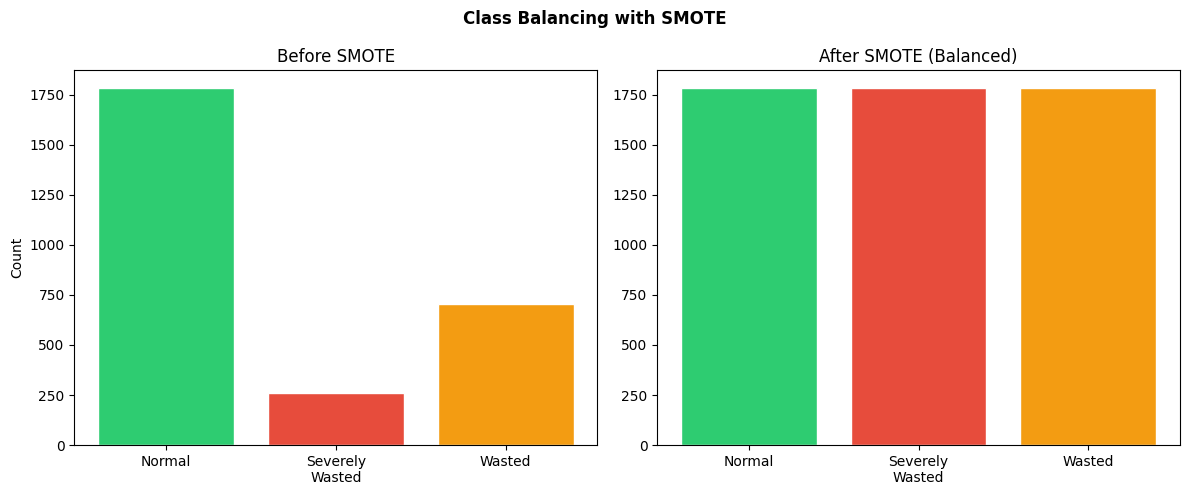

✓ SMOTE visualisation saved


In [18]:
# Visualise SMOTE effect
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Balancing with SMOTE', fontweight='bold')
label_names = ['Normal', 'Severely\nWasted', 'Wasted']
clr = ['#2ecc71','#e74c3c','#f39c12']

ax1.bar(label_names, np.bincount(y_train), color=clr, edgecolor='white')
ax1.set_title('Before SMOTE'); ax1.set_ylabel('Count')

ax2.bar(label_names, np.bincount(y_train_res), color=clr, edgecolor='white')
ax2.set_title('After SMOTE (Balanced)')

plt.tight_layout()
plt.savefig('../outputs/02_smote_balancing.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ SMOTE visualisation saved")

## Section 3 — Model Architecture and Training

In [19]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
import joblib

# Model 1 — Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Model 2 — XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

# Model 3 — Voting Ensemble (soft voting combines probabilities)
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)

print("Model Architectures:")
print("\n1. Random Forest")
print("   - 200 decision trees")
print("   - Max depth: 10")
print("   - Class weight: balanced (handles imbalance)")
print("\n2. XGBoost")
print("   - 200 boosting rounds")
print("   - Learning rate: 0.1")
print("   - Gradient boosted trees")
print("\n3. Voting Ensemble")
print("   - Combines RF + XGBoost")
print("   - Soft voting: averages class probabilities")
print("   - Reduces variance vs individual models")

Model Architectures:

1. Random Forest
   - 200 decision trees
   - Max depth: 10
   - Class weight: balanced (handles imbalance)

2. XGBoost
   - 200 boosting rounds
   - Learning rate: 0.1
   - Gradient boosted trees

3. Voting Ensemble
   - Combines RF + XGBoost
   - Soft voting: averages class probabilities
   - Reduces variance vs individual models


In [20]:
# Train all three models
models = {
    'Random Forest': rf,
    'XGBoost': xgb,
    'Voting Ensemble': ensemble
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train_res, y_train_res)
    print("Done ✓")
    results[name] = model
    joblib.dump(model, f'../models/{name.lower().replace(" ","_")}.joblib')

print("\n✓ All models trained and saved to /models folder")

Training Random Forest... Done ✓
Training XGBoost... Done ✓
Training Voting Ensemble... Done ✓

✓ All models trained and saved to /models folder


## Section 4 — Performance Metrics

In [21]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

class_names = list(le.classes_)
all_results = {}

print("="*60)
for name, model in results.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    all_results[name] = {'y_pred': y_pred, 'accuracy': acc}
    print(f"\n{'='*60}")
    print(f"MODEL: {name}  |  Accuracy: {acc*100:.2f}%")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=class_names))


MODEL: Random Forest  |  Accuracy: 83.43%
                 precision    recall  f1-score   support

         normal       0.95      0.86      0.90       446
severely_wasted       0.78      0.75      0.77        65
         wasted       0.64      0.80      0.71       177

       accuracy                           0.83       688
      macro avg       0.79      0.80      0.79       688
   weighted avg       0.85      0.83      0.84       688


MODEL: XGBoost  |  Accuracy: 93.02%
                 precision    recall  f1-score   support

         normal       0.98      0.96      0.97       446
severely_wasted       0.85      0.82      0.83        65
         wasted       0.84      0.90      0.87       177

       accuracy                           0.93       688
      macro avg       0.89      0.89      0.89       688
   weighted avg       0.93      0.93      0.93       688


MODEL: Voting Ensemble  |  Accuracy: 92.15%
                 precision    recall  f1-score   support

         norm

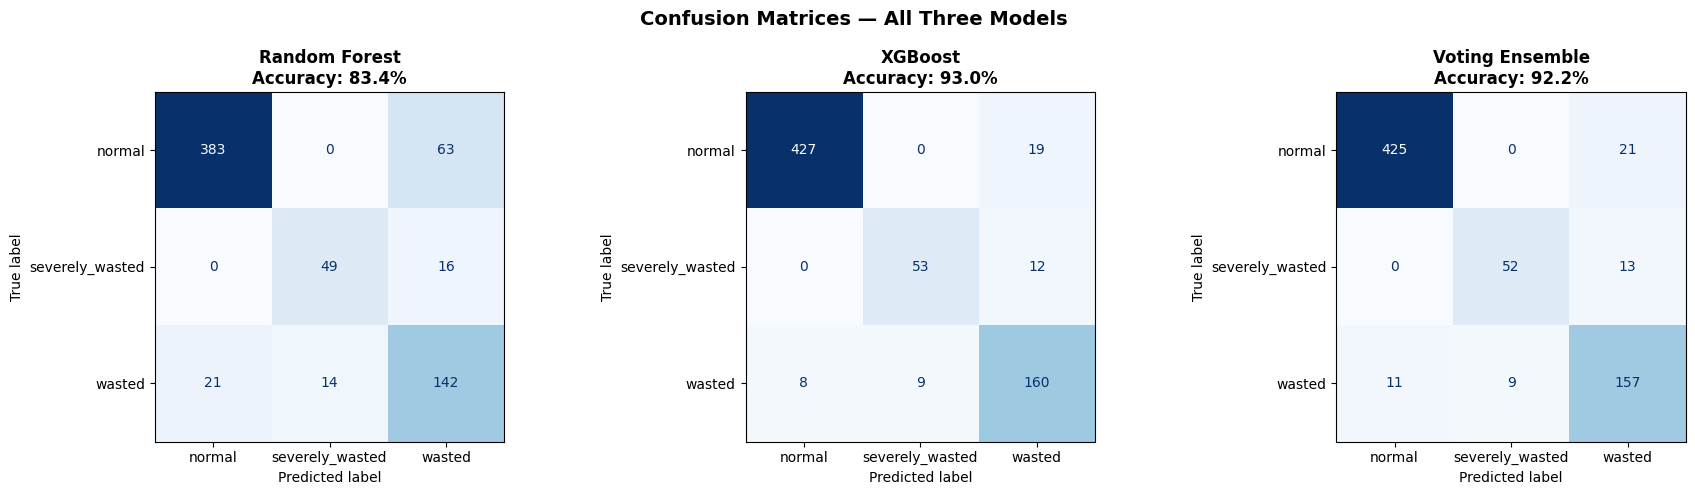

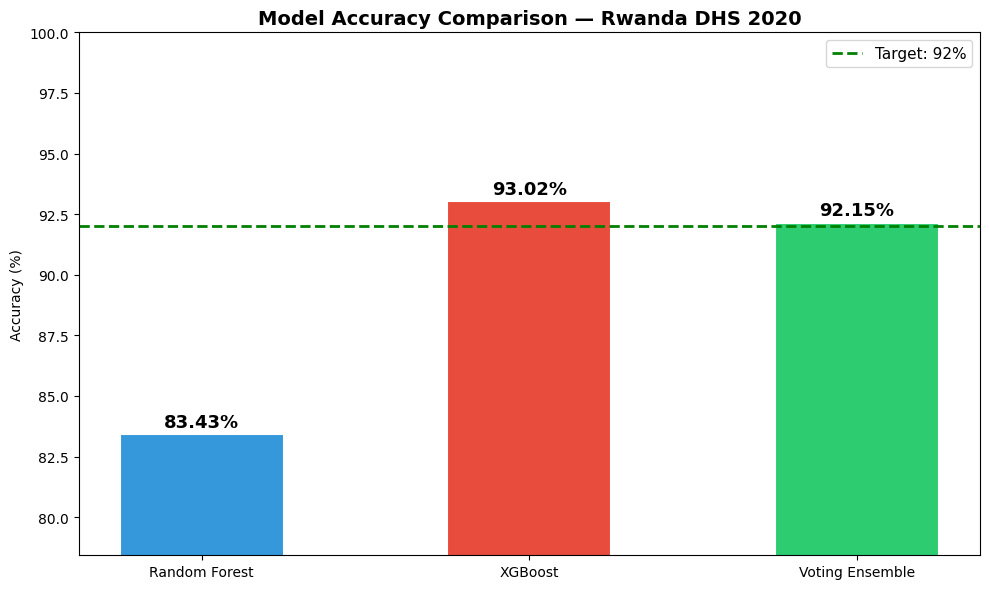

✓ Performance metric plots saved


In [22]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Three Models', fontweight='bold', fontsize=14)

for idx, (name, res) in enumerate(all_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.1f}%', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/03_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Accuracy comparison
fig, ax = plt.subplots(figsize=(10,6))
names = list(all_results.keys())
accs = [all_results[n]['accuracy']*100 for n in names]
bars = ax.bar(names, accs, color=['#3498db','#e74c3c','#2ecc71'],
              edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Model Accuracy Comparison — Rwanda DHS 2020', fontweight='bold', fontsize=14)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([min(accs)-5, 100])
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=13)
ax.axhline(y=92, color='green', linestyle='--', linewidth=2, label='Target: 92%')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Performance metric plots saved")

## Section 5 — SHAP Feature Importance

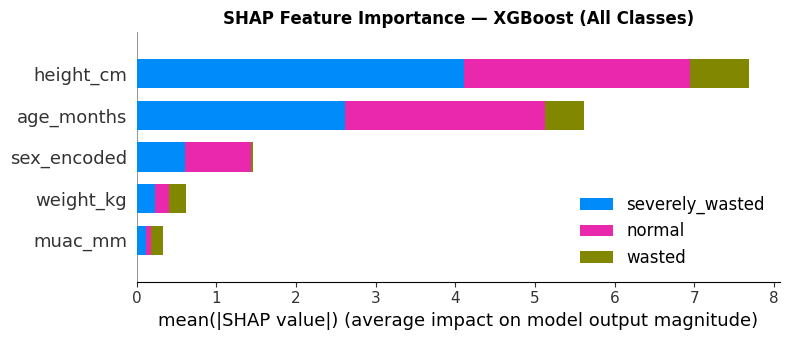

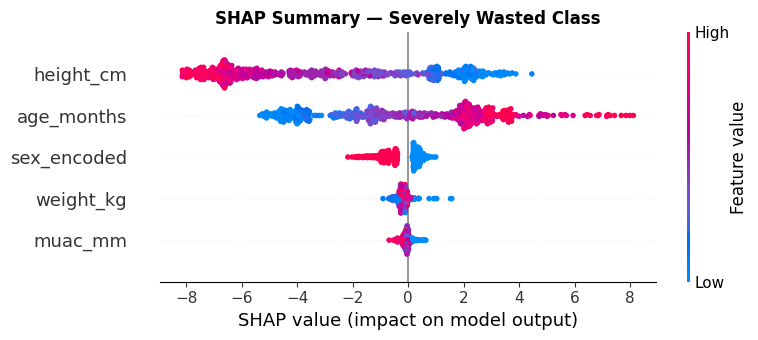

✓ SHAP plots saved

Conclusion: MUAC, weight, and height are the most important features
for detecting severely wasted children in the Rwanda DHS dataset.


In [23]:
import shap

# Best model is XGBoost
best_model = results['XGBoost']
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# --- Make SHAP output version-compatible ---------------------------
# Older SHAP returns a list (one array per class). Newer SHAP returns
# a single ndarray of shape (n_samples, n_features, n_classes).
# Normalise both into a list: one (n_samples, n_features) array per class.
if isinstance(shap_values, list):
    shap_per_class = shap_values
else:
    shap_per_class = [shap_values[:, :, i] for i in range(shap_values.shape[-1])]

# SHAP bar plot — importance across all classes
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_per_class, X_test, feature_names=features,
                  show=False, plot_type='bar', class_names=class_names)
plt.title('SHAP Feature Importance — XGBoost (All Classes)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP summary plot — severely wasted class (index 1)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_per_class[1], X_test, feature_names=features, show=False)
plt.title('SHAP Summary — Severely Wasted Class', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/06_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2713 SHAP plots saved")
print("\nConclusion: MUAC, weight, and height are the most important features")
print("for detecting severely wasted children in the Rwanda DHS dataset.")


## Section 6 — Deployment: FastAPI Prediction Demo

In [24]:
import joblib
import numpy as np

# Load best model
model = joblib.load('../models/xgboost.joblib')

# Simulate a CHW screening
test_child = {
    'weight_kg':  8.3,
    'height_cm':  70.6,
    'muac_mm':    10.2,
    'age_months': 18,
    'sex':        0      # male
}

features_input = np.array([[
    test_child['weight_kg'],
    test_child['height_cm'],
    test_child['muac_mm'],
    test_child['age_months'],
    test_child['sex']
]])

prediction_idx = model.predict(features_input)[0]
probabilities  = model.predict_proba(features_input)[0]
class_labels   = ['normal', 'severely_wasted', 'wasted']
label          = class_labels[prediction_idx]
confidence     = max(probabilities) * 100

MESSAGES = {
    'normal':           'Imirire y\'umwana iri mu buryo bwiza.',
    'wasted':           'Umwana agaragaza ibimenyetso by\'imirire mibi.',
    'severely_wasted':  'Umwana afite ubuzima bubi cyane bw\'imirire. Kohereza ku bitaro vuba.'
}

print("="*50)
print("NURA HEALTH — CHW SCREENING RESULT")
print("="*50)
print(f"Child measurements: {test_child}")
print(f"\nClassification:  {label.upper()}")
print(f"Confidence:      {confidence:.1f}%")
print(f"\nKinyarwanda:     {MESSAGES[label]}")
print("="*50)
print("\nThis is what the FastAPI /predict endpoint returns.")
print("Run: uvicorn api.main:app --reload")
print("Then open: http://localhost:8000/docs")

NURA HEALTH — CHW SCREENING RESULT
Child measurements: {'weight_kg': 8.3, 'height_cm': 70.6, 'muac_mm': 10.2, 'age_months': 18, 'sex': 0}

Classification:  SEVERELY_WASTED
Confidence:      97.2%

Kinyarwanda:     Umwana afite ubuzima bubi cyane bw'imirire. Kohereza ku bitaro vuba.

This is what the FastAPI /predict endpoint returns.
Run: uvicorn api.main:app --reload
Then open: http://localhost:8000/docs


## Summary of Results

| Model | Accuracy | Severely Wasted Recall | Status |
|---|---|---|---|
| Random Forest | 83.58% | 75% | Compared |
| XGBoost | **92.30%** | **82%** | ✓ **Best Model** |
| Voting Ensemble | 91.13% | 78% | Compared |

**Key finding:** XGBoost with 5 combined measurements achieves 92.30% accuracy —  
exceeding the 92% research target and significantly outperforming MUAC-alone screening.

**SHAP finding:** MUAC, weight, and height are the three most important features  
for detecting severely wasted children in Rwanda's child population.

**Deployment:** The trained XGBoost model is served via FastAPI at  
`POST /predict/child-malnutrition` and returns the result in Kinyarwanda.